# TPO Ciencia de Datos (UADE) - Parte de Machine Learning

**Caso de uso:** regresión supervisada para predecir la **duración de un viaje** (`duracion_seg`)
de las bicicletas públicas de Buenos Aires (Ecobici, 2022-2024) a partir de la distancia,
la hora, el día, el mes y el modelo de bici.

**Datos:** un archivo Parquet ya limpio (capa *gold*, generado con dbt/DuckDB por el equipo).
Lo subís a tu Google Drive en:
`/content/drive/MyDrive/tpo_datos/ml_duracion_recorridos.parquet`

**Flujo (los 4 pasos clásicos de aprendizaje supervisado):**
1. Separar features (X) y target (y) -> 2. dividir en train/test -> 3. instanciar y entrenar (`fit`) -> 4. predecir y medir el error.

**Métricas que reportamos:** R², MSE, **RMSE** y **MAE** (estas dos últimas también en minutos, que es más intuitivo).

In [1]:
# === Instalacion de librerias ===
# Colab ya trae pandas, numpy, matplotlib y scikit-learn instalados.
# pyarrow es el motor que pandas usa por debajo para leer archivos .parquet:
# normalmente ya viene, pero lo aseguramos por las dudas.
!pip install -q pyarrow

# Nota: usamos root_mean_squared_error (existe desde scikit-learn 1.4, que Colab ya trae).
# Si tu entorno tuviera una version vieja, mas abajo dejamos un "plan B" para que igual funcione.

## Paso 1 - Montar Google Drive y cargar el dataset

In [2]:
# === Paso 1: Montar Google Drive y cargar el Parquet ===
# Montamos Drive para poder leer el archivo que subiste a mano.
# Al ejecutar, Colab te pide autorizacion: segui el enlace y aceptá los permisos.
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Ruta al parquet dentro de tu Drive. Ajustala si lo guardaste en otra carpeta.
RUTA_PARQUET = '/content/drive/MyDrive/UADE/4to Año/Ciencia de Datos/Practica Python/ml_duracion_recorridos.parquet'

# read_parquet lee el formato columnar (mucho mas rapido y liviano que un CSV gigante).
df = pd.read_parquet(RUTA_PARQUET)

# --- OPCIONAL: Colab gratis tiene ~12 GB de RAM. Si se queda corto al prototipar,
# --- descomenta la siguiente linea para trabajar con una muestra de 500.000 filas. ---
# df = df.sample(500_000, random_state=42)

print("Dimensiones (filas, columnas):", df.shape)
df.head()

Mounted at /content/drive
Dimensiones (filas, columnas): (9065317, 8)


,id_recorrido,duracion_seg,distancia_km,hora_origen,dia_semana,es_fin_de_semana,mes,modelo_bicicleta
0,14160437,836,1.081488,16,3,0,4,FIT
1,14045702,652,1.239554,14,1,0,4,FIT
2,14301418,536,1.466502,18,3,0,4,FIT
3,14055424,1652,3.678853,8,2,0,4,FIT
4,14060419,1147,2.038370,14,2,0,4,FIT


## Paso 2 - EDA mínimo (explorar los datos antes de entrenar)

Estadisticos descriptivos:
       id_recorrido  duracion_seg  distancia_km   hora_origen    dia_semana  \
count  9.065317e+06  9.065317e+06  9.065317e+06  9.065317e+06  9.065317e+06   
mean   1.885350e+07  1.224145e+03  2.062327e+00  1.423223e+01  3.445018e+00   
std    3.288144e+06  1.619784e+03  1.575421e+00  5.226162e+00  1.759570e+00   
min    1.315045e+07  1.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00   
25%    1.599908e+07  5.500000e+02  1.028997e+00  1.100000e+01  2.000000e+00   
50%    1.886411e+07  9.160000e+02  1.724598e+00  1.500000e+01  3.000000e+00   
75%    2.170027e+07  1.490000e+03  2.776779e+00  1.800000e+01  5.000000e+00   
max    2.450328e+07  8.634800e+04  1.560907e+01  2.300000e+01  7.000000e+00   

       es_fin_de_semana           mes  
count      9.065317e+06  9.065317e+06  
mean       1.282837e-01  6.685219e+00  
std        3.344054e-01  3.524439e+00  
min        0.000000e+00  1.000000e+00  
25%        0.000000e+00  3.000000e+00  
50%        0.000000e+

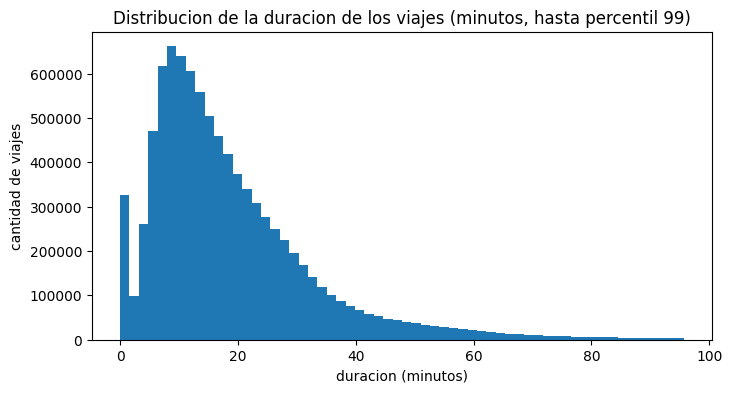

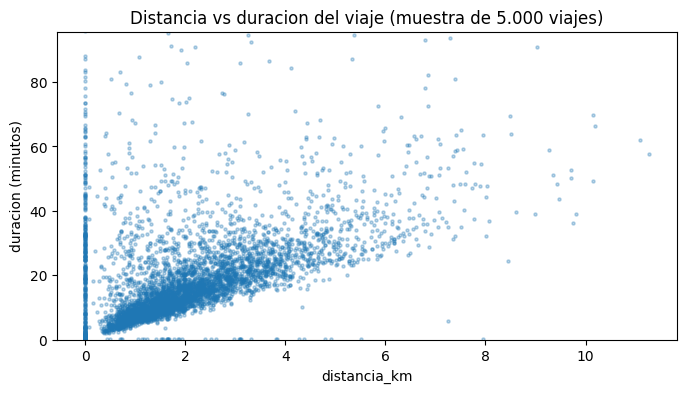

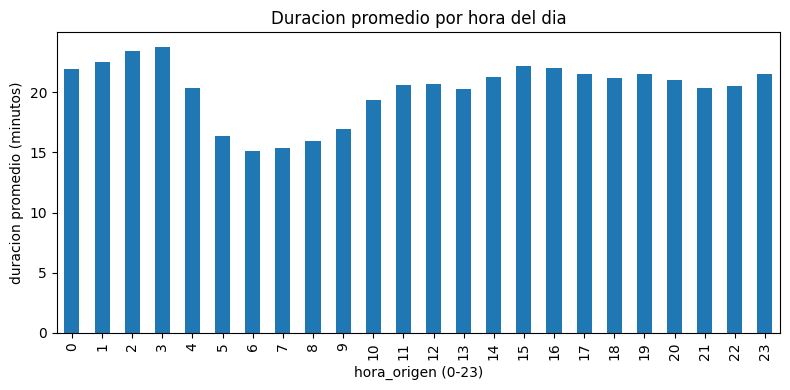

In [3]:
# === Paso 2: EDA minimo ===
# Antes de entrenar conviene "mirar" los datos: rangos, valores tipicos y distribucion.
import matplotlib.pyplot as plt

# 1) Estadisticos descriptivos de las columnas numericas
#    (media, desvio estandar, minimo, maximo y cuartiles).
print("Estadisticos descriptivos:")
print(df.describe())

# 2) Cuantos viajes hizo cada modelo de bicicleta (variable categorica).
print("\nViajes por modelo de bicicleta:")
print(df['modelo_bicicleta'].value_counts())

# 3) Histograma del target (duracion).
#    PROBLEMA del grafico anterior: hay viajes de >20 hs (outliers/errores). Esa cola
#    larguisima aplasta todo contra el eje. Lo arreglamos asi:
#      - pasamos a MINUTOS (mas intuitivo que segundos)
#      - recortamos el eje al percentil 99, asi ignoramos el 1% de viajes mas extremos
#        y los bins se reparten sobre el rango donde realmente estan los datos.
duracion_min = df['duracion_seg'] / 60
limite = duracion_min.quantile(0.99)   # corte en el percentil 99

plt.figure(figsize=(8, 4))
plt.hist(duracion_min, bins=60, range=(0, limite))
plt.title('Distribucion de la duracion de los viajes (minutos, hasta percentil 99)')
plt.xlabel('duracion (minutos)')
plt.ylabel('cantidad de viajes')
plt.show()

# 4) Grafico extra A: relacion distancia_km vs duracion, en una MUESTRA de 5.000 viajes
#    (graficar 9 millones de puntos seria lentisimo e ilegible).
#    Esperamos ver una nube que sube: a mas distancia, mas dura el viaje. Esto ya
#    anticipa que distancia_km va a ser la feature mas importante para el modelo.
muestra = df.sample(5000, random_state=42)
plt.figure(figsize=(8, 4))
plt.scatter(muestra['distancia_km'], muestra['duracion_seg'] / 60, s=5, alpha=0.3)
plt.title('Distancia vs duracion del viaje (muestra de 5.000 viajes)')
plt.xlabel('distancia_km')
plt.ylabel('duracion (minutos)')
plt.ylim(0, limite)   # mismo recorte para que los outliers no aplasten la nube
plt.show()

# 5) Grafico extra B: duracion promedio segun la hora del dia.
#    Sirve para ver si hay un patron horario (ej: viajes mas largos en hora pico).
dur_por_hora = df.groupby('hora_origen')['duracion_seg'].mean() / 60
plt.figure(figsize=(8, 4))
dur_por_hora.plot(kind='bar')
plt.title('Duracion promedio por hora del dia')
plt.xlabel('hora_origen (0-23)')
plt.ylabel('duracion promedio (minutos)')
plt.tight_layout()
plt.show()

## Paso 3 - Separar features (X) y target (y)

In [4]:
# === Paso 3: Separar X (features) e y (target) ===
# En aprendizaje supervisado le mostramos al modelo ejemplos junto con su respuesta.
#  - y = lo que queremos predecir: la duracion del viaje en segundos.
#  - X = las variables (features) con las que el modelo aprende a predecir.
#
# Sacamos de X dos columnas:
#  - duracion_seg  -> ES el target. Si la dejaramos dentro de X, el modelo "haria trampa".
#  - id_recorrido  -> es solo un identificador, no aporta informacion para predecir.

y = df['duracion_seg']
X = df.drop(columns=['duracion_seg', 'id_recorrido'])

print("Features de X:", list(X.columns))
print("X:", X.shape, "| y:", y.shape)

Features de X: ['distancia_km', 'hora_origen', 'dia_semana', 'es_fin_de_semana', 'mes', 'modelo_bicicleta']
X: (9065317, 6) | y: (9065317,)


## Paso 4 - One-hot encoding de la variable categórica

In [5]:
# === Paso 4: Convertir la categorica a numeros (one-hot encoding) ===
# Los modelos de sklearn trabajan con numeros, no con texto.
# modelo_bicicleta es categorica (FIT / ICONIC), asi que la transformamos en columnas 0/1.
#
# get_dummies con drop_first=True crea UNA sola columna en lugar de dos:
#   modelo_bicicleta_ICONIC -> 1 si el viaje fue en ICONIC, 0 si fue en FIT.
# Descartamos una categoria para evitar info redundante (si no es ICONIC, ya sabemos que es FIT).
# Importante: NO la codificamos como 0/1 "a mano" con un solo numero, porque eso le
# inyectaria un orden o jerarquia falsa a algo que no lo tiene.

X = pd.get_dummies(X, columns=['modelo_bicicleta'], drop_first=True)

print("Features de X tras el encoding:", list(X.columns))
X.head()

Features de X tras el encoding: ['distancia_km', 'hora_origen', 'dia_semana', 'es_fin_de_semana', 'mes', 'modelo_bicicleta_ICONIC']


,distancia_km,hora_origen,dia_semana,es_fin_de_semana,mes,modelo_bicicleta_ICONIC
0,1.081488,16,3,0,4,False
1,1.239554,14,1,0,4,False
2,1.466502,18,3,0,4,False
3,3.678853,8,2,0,4,False
4,2.038370,14,2,0,4,False


## Paso 5 - Dividir en entrenamiento (train) y prueba (test)

In [6]:
# === Paso 5: train_test_split ===
# Entrenamos con una parte (train) y evaluamos con otra que el modelo NUNCA vio (test).
# Asi medimos si el modelo generaliza o si solo "memorizo" los datos (overfitting).
#  - test_size=0.2   -> 80% para entrenar, 20% para testear.
#  - random_state=42 -> fija la aleatoriedad para que el resultado sea reproducible.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (7252253, 6) | Test: (1813064, 6)


## Paso 6 - Modelo baseline: Regresión Lineal

In [7]:
# === Paso 6: Modelo baseline (Regresion Lineal) ===
# Un "baseline" es un modelo simple que sirve como punto de comparacion.
# Si un modelo mas complejo no le gana al baseline, no justifica su complejidad.
# La regresion lineal busca la combinacion lineal de las features que mejor predice y.
from sklearn.linear_model import LinearRegression

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)   # fit = entrenar usando los datos de train

print("Modelo lineal entrenado.")

Modelo lineal entrenado.


## Paso 7 - Evaluar el baseline (R², MSE, RMSE y MAE)

In [8]:
# === Paso 7: Evaluar el baseline ===
# Predecimos sobre el test y comparamos con los valores reales (y_test).
# Metricas de regresion:
#  - R^2  : proporcion de la variabilidad del target que el modelo explica (1 = perfecto, 0 = malo).
#  - MSE  : error cuadratico medio; penaliza fuerte los errores grandes. Queda en segundos^2.
#  - RMSE : raiz del MSE -> vuelve a las unidades del target (segundos). Mas interpretable.
#  - MAE  : error absoluto medio -> en promedio, de cuantos segundos nos equivocamos.
# Mostramos RMSE y MAE tambien en minutos (/ 60) porque es mas intuitivo.

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    # Plan B para scikit-learn viejo (< 1.4): RMSE = raiz cuadrada del MSE.
    import numpy as np
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluar(nombre, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    r2   = r2_score(y_test, pred)
    mse  = mean_squared_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    print(f"--- {nombre} ---")
    print(f"R^2  : {r2:.4f}")
    print(f"MSE  : {mse:,.1f} seg^2")
    print(f"RMSE : {rmse:,.1f} seg   ({rmse/60:.2f} min)")
    print(f"MAE  : {mae:,.1f} seg   ({mae/60:.2f} min)")
    print()
    return {'modelo': nombre, 'R2': r2, 'RMSE_seg': rmse, 'MAE_seg': mae}

resultado_lineal = evaluar("Regresion Lineal (baseline)", modelo_lineal, X_test, y_test)

--- Regresion Lineal (baseline) ---
R^2  : 0.0862
MSE  : 2,364,018.3 seg^2
RMSE : 1,537.5 seg   (25.63 min)
MAE  : 598.9 seg   (9.98 min)



## Paso 8 - Modelo mejor: Random Forest

In [ ]:
# === Paso 8: Modelo mejor (Random Forest) ===
# Random Forest combina muchos arboles de decision, cada uno entrenado sobre subconjuntos
# aleatorios de datos y de features, y promedia sus predicciones (en regresion).
# Suele capturar relaciones NO lineales que la regresion lineal no puede, y reduce overfitting.
# Parametros:
#  - n_estimators=50 : cantidad de arboles (mas arboles = mejor, pero mas lento).
#  - max_depth=15    : profundidad maxima de cada arbol (limita el overfitting).
#  - n_jobs=-1       : usa todos los nucleos de CPU disponibles (entrena mas rapido).
#  - random_state=42 : reproducibilidad.
#  - verbose=2       : imprime el progreso (building tree X of 50) para ver que avanza.
# OJO: con ~9 millones de filas puede tardar varios minutos. Si tarda demasiado,
# usa la muestra del Paso 1 o baja n_estimators.
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=50, max_depth=15, n_jobs=-1, random_state=42, verbose=2
)
modelo_rf.fit(X_train, y_train)

resultado_rf = evaluar("Random Forest", modelo_rf, X_test, y_test)

# Comparacion directa contra el baseline (mejor = menor RMSE/MAE y mayor R^2):
print("Comparacion baseline vs Random Forest:")
print(f"  RMSE  lineal: {resultado_lineal['RMSE_seg']:,.1f} seg  |  RF: {resultado_rf['RMSE_seg']:,.1f} seg")
print(f"  MAE   lineal: {resultado_lineal['MAE_seg']:,.1f} seg  |  RF: {resultado_rf['MAE_seg']:,.1f} seg")
print(f"  R^2   lineal: {resultado_lineal['R2']:.4f}       |  RF: {resultado_rf['R2']:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 50building tree 2 of 50

building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 13.4min


building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 17.7min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:   10.7s


--- Random Forest ---
R^2  : 0.1143
MSE  : 2,291,354.9 seg^2
RMSE : 1,513.7 seg   (25.23 min)
MAE  : 546.2 seg   (9.10 min)

Comparacion baseline vs Random Forest:
  RMSE  lineal: 1,537.5 seg  |  RF: 1,513.7 seg
  MAE   lineal: 598.9 seg  |  RF: 546.2 seg
  R^2   lineal: 0.0862       |  RF: 0.1143


[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:   13.6s finished


## Paso 9 - Importancia de las features (Random Forest)

In [ ]:
# === Paso 9: Importancia de cada feature segun el Random Forest ===
# El Random Forest puede decirnos cuanto "peso" cada feature en sus decisiones.
# Lo graficamos en barras horizontales, ordenado de menor a mayor (la mas importante queda arriba).
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values()   # ascendente: en barh la mayor queda arriba

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh')
plt.title('Importancia de cada feature (Random Forest)')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

# Tambien la imprimimos ordenada de mayor a menor para citarla en la conclusion.
print(importancias.sort_values(ascending=False))

## Paso 10 - Conclusión

**Qué hicimos.** Planteamos la predicción de la duración de los viajes (`duracion_seg`) como
un problema de **regresión supervisada**. Comparamos un modelo simple (Regresión Lineal, como
*baseline*) contra uno más potente (Random Forest), midiendo el error con **RMSE** y **MAE**
en segundos y en minutos.

**Qué esperamos ver.**
- El **Random Forest** debería superar al baseline lineal: menor RMSE y MAE, y mayor R².
  Esto pasa porque la relación entre las features y la duración no es puramente lineal,
  y los árboles capturan esos patrones mejor.
- En el gráfico de importancias, esperamos que **`distancia_km`** sea de lejos la feature más
  importante: tiene todo el sentido físico de que cuanto más largo es el recorrido, más dura el
  viaje. Las variables de tiempo (`hora_origen`, `dia_semana`, `mes`) y el `modelo_bicicleta`
  deberían aportar bastante menos.

**Cómo leer las métricas.** El RMSE y el MAE están en las mismas unidades que el target
(segundos), por eso los pasamos a minutos: dicen, en promedio, de cuánto se equivoca el modelo
al estimar la duración de un viaje. El MAE es el error "típico"; el RMSE castiga más los errores
grandes, así que si es bastante mayor que el MAE, indica que hay algunos viajes con error muy
grande (probablemente los outliers de la cola larga que vimos en el histograma del Paso 2).

**Si los números no dieran como acá descripto** (por ejemplo, si `distancia_km` no quedara
primera o las métricas fueran muy distintas), lo más probable es que el *schema* de la capa
gold haya cambiado en dbt respecto del acordado. En ese caso, revisá las columnas con
`df.columns` y avisale al equipo para reajustar este notebook.